In [32]:
# To implement L2 Regularization and Dropout techniques in
# an Artificial Neural Network and compare their performance with a model
# without regularization.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
# ===============================
# Load Dataset
# ===============================
data = pd.read_csv("heart.csv")
print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [34]:
# ===============================
# Split Features and Target
# ===============================
X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
# ===============================
# Feature Scaling
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
# ==========================================================
# Model 1 : Without Regularization
# ==========================================================

model1 = Sequential()

model1.add(Input(shape=(X_train.shape[1],)))
model1.add(Dense(16, activation='relu'))
model1.add(Dense(8, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [37]:
# ==========================================================
# Model 2 : L2 Regularization
# ==========================================================

model2 = Sequential()

model2.add(Input(shape=(X_train.shape[1],)))
model2.add(Dense(16,
                 activation='relu',
                 kernel_regularizer=l2(0.01)))
model2.add(Dense(8,
                 activation='relu',
                 kernel_regularizer=l2(0.01)))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [38]:
# ==========================================================
# Model 3 : Dropout
# ==========================================================

model3 = Sequential()

model3.add(Input(shape=(X_train.shape[1],)))
model3.add(Dense(16, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(8, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [39]:
# ==========================================================
# Model 4 : Early Stopping
# ==========================================================

model4 = Sequential()

model4.add(Input(shape=(X_train.shape[1],)))
model4.add(Dense(16, activation='relu'))
model4.add(Dropout(0.5))
model4.add(Dense(8, activation='relu'))
model4.add(Dropout(0.5))
model4.add(Dense(1, activation='sigmoid'))

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history4 = model4.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

In [40]:
# ==========================================================
# Evaluate Models
# ==========================================================

# loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
# loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
# loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
# loss4, acc4 = model4.evaluate(X_test, y_test, verbose=0)

# print("\nTest Accuracy")
# print("-----------------------------")
# print(f"Without Regularization : {acc1:.4f}")
# print(f"L2 Regularization      : {acc2:.4f}")
# print(f"Dropout               : {acc3:.4f}")
# print(f"Early Stopping        : {acc4:.4f}")

a1 = model1.evaluate(X_test, y_test, verbose=0)[1]
a2 = model2.evaluate(X_test, y_test, verbose=0)[1]
a3 = model3.evaluate(X_test, y_test, verbose=0)[1]
a4 = model4.evaluate(X_test, y_test, verbose=0)[1]

print("\nTest Accuracy")
print("-----------------------------")
print(f"Without Regularization : ",round(a1 * 100, 2),"%")
print(f"L2 Regularization      : ",round(a2 * 100, 2),"%")
print(f"Dropout               : ",round(a3 * 100, 2),"%")
print(f"Early Stopping        : ",round(a4 * 100, 2),"%")


Test Accuracy
-----------------------------
Without Regularization :  81.97 %
L2 Regularization      :  77.05 %
Dropout               :  70.49 %
Early Stopping        :  77.05 %


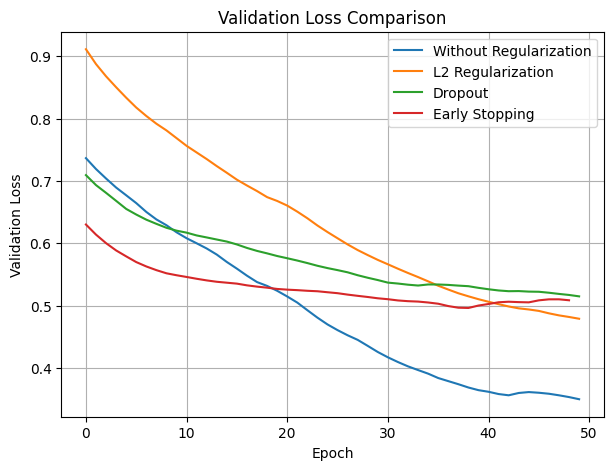

In [41]:
# # ==========================================================
# # Plot Validation Accuracy
# # ==========================================================

# plt.figure(figsize=(10,5))

# plt.plot(history1.history['val_accuracy'], label='Without Regularization')
# plt.plot(history2.history['val_accuracy'], label='L2 Regularization')
# plt.plot(history3.history['val_accuracy'], label='Dropout')
# plt.plot(history4.history['val_accuracy'], label='Early Stopping')

# plt.title("Validation Accuracy Comparison")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()

# # ==========================================================
# # Plot Validation Loss
# # ==========================================================

# plt.figure(figsize=(10,5))

# plt.plot(history1.history['val_loss'], label='Without Regularization')
# plt.plot(history2.history['val_loss'], label='L2 Regularization')
# plt.plot(history3.history['val_loss'], label='Dropout')
# plt.plot(history4.history['val_loss'], label='Early Stopping')

# plt.title("Validation Loss Comparison")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

plt.figure(figsize=(7,5))
plt.plot(history1.history['val_loss'], label='Without Regularization')
plt.plot(history2.history['val_loss'], label='L2 Regularization')
plt.plot(history3.history['val_loss'], label='Dropout')
plt.plot(history4.history['val_loss'], label='Early Stopping')
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()